##Importing Libraries

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pandas.tseries.offsets import DateOffset, BDay
from scipy.interpolate import interp1d

##Inputs

In [13]:
valuationDate = pd.Timestamp("2026-07-14")

data = {"Tenure": ["1D", "1M", "2M", "3M", "6M", "9M", "1Y", "2Y", "3Y", "4Y", "5Y"],
         "rate": [5.3, 5.34, 5.35, 5.36, 5.47, 5.61, 5.75, 5.89, 6.0, 6.07, 6.16]}

df = pd.DataFrame(data)

##Data Formatting

In [6]:
def tenure_to_date(start, tenor):

  value = int(tenor[:-1])
  unit = tenor[-1]

  if unit == 'D':
    return start + pd.Timedelta(days= value)
  elif unit == 'M':
    return start + DateOffset(months= value)
  elif unit == 'Y':
    return start + DateOffset(years= value)
  else:
    raise ValueError(f'Unknown tenure format {tenor}')

df['maturity'] = df['Tenure'].apply(lambda x: tenure_to_date(valuationDate, x))

df["maturity"] = df["maturity"].apply(lambda x: x if x.weekday() < 5 else x + BDay())

##Bootstrapping OIS

In [14]:
# OIS Bootstrapping equation

def bootstrap_ois(df, valuation_date):
  """
  Bootstrap discount factors from OIS quotes.

  Parameters
  ----------
  df : DataFrame
      Columns:
          maturity_date
          ois_rate (percent)

  valuation_date : Timestamp

  Returns
  -------
  DataFrame
  """

  # df = df.sort_values("maturity_date").copy()

  discount_factors = []
  alphas = []

  for i in range(len(df)):

    maturity = df.iloc[i]["maturity"]
    r = df.iloc[i]["rate"] / 100

    # ACT/365 accrual from previous payment
    if i == 0:
      previous = valuation_date
    else:
      previous = df.iloc[i-1]["maturity"]

    alpha = (maturity - previous).days / 365
    alphas.append(alpha)

    # Sum over already bootstrapped coupons
    pv_known = 0.0
    for j in range(i):
      pv_known += r * alphas[j] * discount_factors[j]

    # Recursive bootstrap equation
    P = (1 - pv_known) / (1 + r * alpha)

    discount_factors.append(P)

  df["alpha"] = alphas
  df["discount_factor"] = discount_factors

  # Continuous zero rates
  T = (df["maturity"] - valuation_date).dt.days / 365

  df["zero_rate"] = -np.log(df["discount_factor"]) / T

  return df

In [8]:
bootstrap_ois(df, valuationDate)

df["maturity"] = pd.to_datetime(df["maturity"])

df["time"] = (df["maturity"] - valuationDate).dt.days / 365.0
df.head()

,Tenure,rate,maturity,alpha,discount_factor,zero_rate,time
0,1D,5.30,2026-07-15,0.002740,0.999855,0.052996,0.002740
1,1M,5.34,2026-08-14,0.082192,0.995484,0.053287,0.084932
2,2M,5.35,2026-09-14,0.084932,0.990973,0.053383,0.169863
3,3M,5.36,2026-10-14,0.082192,0.986610,0.053483,0.252055
4,6M,5.47,2027-01-14,0.252055,0.972921,0.054457,0.504110


##Log-Linear Interpolation

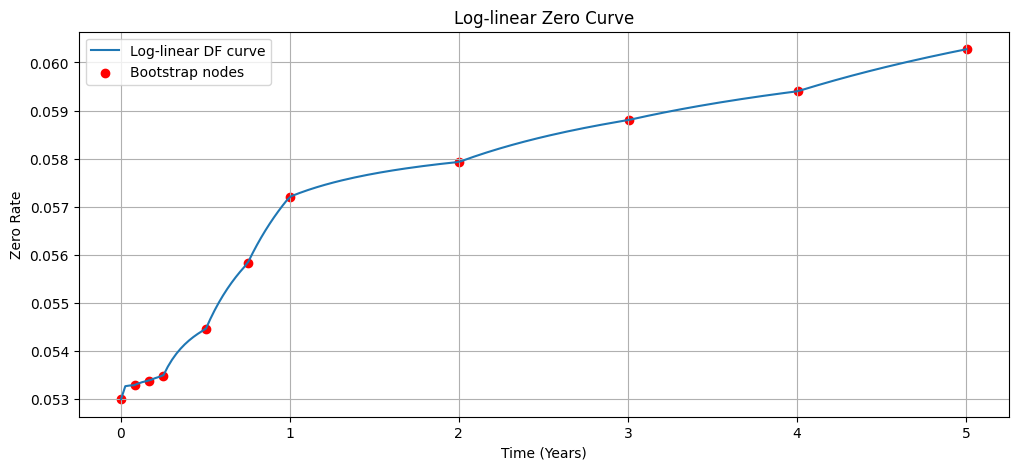

In [12]:
times = df["time"].to_numpy()
dfs = df["discount_factor"].to_numpy()

log_df = np.log(dfs)

interp_log_df = interp1d(times, log_df, kind="linear", fill_value="extrapolate")

t = np.linspace(times[0], times[-1], 200)

discount_curve = np.exp(interp_log_df(t))

zero_curve = -np.log(discount_curve) / t

plt.figure(figsize=(12,5))

plt.plot(t, zero_curve, label="Log-linear DF curve")
plt.scatter(times, df['zero_rate'], color="red", label="Bootstrap nodes")

plt.xlabel("Time (Years)")
plt.ylabel("Zero Rate")
plt.title("Log-linear Zero Curve")
plt.grid(True)
plt.legend()

plt.show()

##Curve Validation

In [10]:
t = (pd.Timestamp("2028-06-26") - valuationDate).days/ 365.0

discount_r = np.exp(interp_log_df(t))

zero_r = -np.log(discount_r) / t
zero_r

np.float64(0.05791378191297782)